   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.8/70.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.4/230.4 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 820.4/820.4 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.3/134.3 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 408.3/408.3 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 33.1 MB/s eta 0:00:00

Daily data
       year         month  day  temperature_2m_min  \
0     2019 -2.449294e-16   20              -13.75   
1     2019 -2.449294e-16   21              -11.75   
...    ...           ...  ...                 ...   
2212  2026  5.000000e-01    9                1.05   
2213  2026  5.000000e-01   10               -2.10   

      wind_direction_10m_dominant_sin  wind_gusts_10m_max  rain_sum  \
0                           -0.999955    

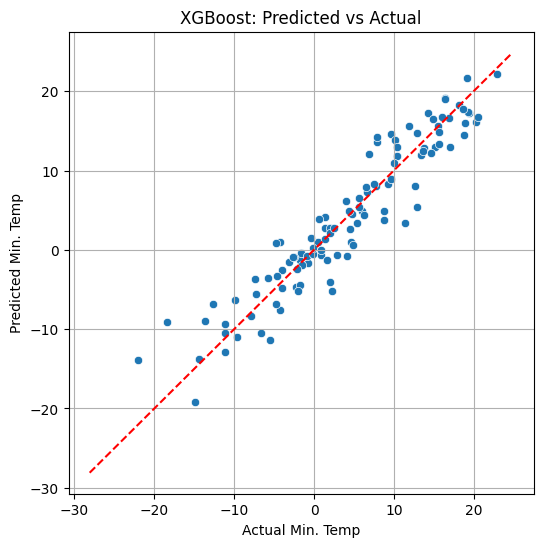

In [ ]:
!pip install openmeteo_requests requests_cache retry_requests xgboost scikit-learn --quiet

import openmeteo_requests

import pandas as pd
import numpy
import requests_cache
from retry_requests import retry
from xgboost import XGBRegressor


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 5)

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
	"latitude": 43.5,
	"longitude": -79.9,
	"start_date": "2019-12-20",
	"end_date": "2026-01-10",
	"daily": ["temperature_2m_min", "wind_direction_10m_dominant", "wind_gusts_10m_max", "rain_sum", "snowfall_sum", "wind_speed_10m_max", "relative_humidity_2m_mean", "cloud_cover_mean"],
}
responses = openmeteo.weather_api(url, params = params)

response = responses[0]


# Process daily data.
daily = response.Daily()
daily_temperature_2m_min = daily.Variables(0).ValuesAsNumpy()
daily_wind_direction_10m_dominant = daily.Variables(1).ValuesAsNumpy()
daily_wind_gusts_10m_max = daily.Variables(2).ValuesAsNumpy()
daily_rain_sum = daily.Variables(3).ValuesAsNumpy()
daily_snowfall_sum = daily.Variables(4).ValuesAsNumpy()
daily_wind_speed_10m_max = daily.Variables(5).ValuesAsNumpy()
daily_relative_humidity_2m_mean = daily.Variables(6).ValuesAsNumpy()
daily_cloud_cover_mean = daily.Variables(7).ValuesAsNumpy()

daily_data = {
	"date": pd.date_range(
		start = pd.to_datetime(daily.Time(), unit = "s", utc = True),
		end =  pd.to_datetime(daily.TimeEnd(), unit = "s", utc = True),
		freq = pd.Timedelta(seconds = daily.Interval()),
		inclusive = "left"
	)
}



daily_data["year"] = daily_data["date"].year
daily_data["month"] = numpy.sin(2 * numpy.pi * daily_data["date"].month/12) #tell model that temp is cyclical
daily_data["day"] = daily_data["date"].day
daily_data["temperature_2m_min"] = daily_temperature_2m_min
daily_data["wind_direction_10m_dominant_sin"] = numpy.sin(daily_wind_direction_10m_dominant) #allow for wind direction to wrap around thanks to sine
daily_data["wind_gusts_10m_max"] = daily_wind_gusts_10m_max
daily_data["rain_sum"] = daily_rain_sum
daily_data["snowfall_sum"] = daily_snowfall_sum
daily_data["wind_speed_10m_max"] = daily_wind_speed_10m_max
daily_data["relative_humidity_2m_mean"] = daily_relative_humidity_2m_mean
daily_data["cloud_cover_mean"] = daily_cloud_cover_mean

daily_df = pd.DataFrame(data = daily_data)
daily_df = daily_df.drop("date", axis=1) #drop date column which has been processed into year month and day

daily_df["min_temp_previous_day"] = daily_df["temperature_2m_min"].shift(periods=1, axis=0) #previous day temp data
daily_df["min_temp_previous_week"] = daily_df["temperature_2m_min"].shift(periods=7, axis=0) #previous week temp data

daily_df.drop(range(0,11), axis=0) #drop first 11 rows
daily_df.drop(range(2204, 2213), axis=0) #drop rows in 2026

features = daily_df.columns.tolist()
output_feature = "temperature_2m_min"
features.remove(output_feature)
date_features = ["year", "month", "day"]


for date_feature in date_features:
  features.remove(date_feature)

print("\nDaily data\n", daily_df)
print(features)


#standardize data
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

x = daily_df.drop(output_feature, axis=1)
y = daily_df[output_feature]

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.05, random_state=42) #split data before standardizing

#z-score normalize
preprocess = ColumnTransformer([
    ('num', StandardScaler(), features)
])

xgbmodel = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.15,
    random_state=42,
    max_depth=5
)

xgb_pipeline = Pipeline([
    ('pre', preprocess),
    ('model', xgbmodel)
])

xgb_pipeline.fit(X_train, y_train)
y_pred = xgb_pipeline.predict(X_test)


print("XGBoost")
print("R²:", r2_score(y_test, y_pred))
print("RMSE:", numpy.sqrt(mean_squared_error(y_test, y_pred)))

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Min. Temp")
plt.ylabel("Predicted Min. Temp")
plt.title("XGBoost: Predicted vs Actual")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.grid()
plt.show()